# Eddies vs Ekman pumping

EIP pumping theory relies on changes in EKman pumpin. Lets calcualte the total Ekman pumpin in each simulation and see if it actually increases with resolution

**This notebook needs to be run in a hugemem queue. Importing the daily fields also take a considerable time**

In [1]:
import intake
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import cartopy.crs as ccrs
import cf_xarray as cf
import xarray as xr
import cmocean.cm as cmocean
import glob
from mpl_toolkits.axes_grid1 import make_axes_locatable
import shutil as shutil
from dask.distributed import Client
from scipy import ndimage
from skimage import measure
import pandas as pd
import plotly.express as px
import warnings

In [2]:
client = Client(threads_per_worker = 1,memory_limit='2900gb')

2025-10-08 16:03:11,751 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 2900gb due to system memory limit of 1.43 TiB
2025-10-08 16:03:11,754 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 2900gb due to system memory limit of 1.43 TiB
2025-10-08 16:03:11,757 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 2900gb due to system memory limit of 1.43 TiB
2025-10-08 16:03:11,759 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 2900gb due to system memory limit of 1.43 TiB
2025-10-08 16:03:11,761 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 2900gb due to system memory limit of 1.43 TiB
2025-10-08 16:03:11,764 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 2900gb due to system memory limit of 1.43 TiB
2025-10-08 16:03:11,766 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 2900gb due to system memory limit of 1.43 TiB
2025-10-08 16:03:11,

In [3]:
#setting the reference rho
rho_ref = 1035 #kg m^{-3}, used as standard by Pan-Antarctic
#using a single year of data
start_date='2000-01-01'
end_date = '2001-01-01'

In [4]:
#in this definition, no frequency can be used only for static data
catalog = intake.cat.access_nri
def importer(experiment,catalog,variable, frequency = 'fx',start_time=0,end_time=0):
    warnings.filterwarnings('ignore')
    if experiment== "panant-01-zstar-ACCESSyr2":
        var = catalog[experiment].search(variable=variable, frequency = frequency).to_dask(xarray_open_kwargs={'decode_timedelta':True})
    else: 
        #other resolutions have the same variable with z_l and z_l_sub z dim in different times.
        # I will filter to the time I want knowing th their specificities
        #IOW this fix works just for the models and variables used in this notebook
        if variable=='uo' or variable=='vo':
            var = catalog[experiment].search(variable=variable, frequency = frequency)
            keysnames = var.keys() ; search_term = "z_l_sub01"
            matches = [s for s in keysnames if search_term in s]
            var = catalog[experiment].search(variable=variable, frequency = frequency,file_id = matches).to_dask(xarray_open_kwargs={'decode_timedelta':True})
        else:
            var = catalog[experiment].search(variable=variable, frequency = frequency).to_dask(xarray_open_kwargs={'decode_timedelta':True})
    
    if start_time!=0:
        time_slice='slice(start_time,end_time)'
        return eval("var." + variable + ".sel(time=" + time_slice + ")")
    elif start_time ==0:
        return eval("var." + variable)

In [9]:
%%time
# importing annual mean mean wind stresses
#importing tau u
τu_0025 = importer("panant-0025-zstar-ACCESSyr2",catalog,"tauuo",frequency = '1mon',start_time = start_date, end_time =end_date).chunk(chunks={'xq':'15gb','yh':'15gb','time':'15gb'}).mean('time').compute()
τu_005 = importer("panant-005-zstar-ACCESSyr2",catalog,"tauuo",frequency = '1mon',start_time = start_date, end_time =end_date).chunk(chunks={'xq':'15gb','yh':'15gb','time':'15gb'}).mean('time').compute()
τu_01 = importer("panant-01-zstar-ACCESSyr2",catalog,"tauuo",frequency = '1mon',start_time = start_date, end_time =end_date).chunk(chunks={'xq':'15gb','yh':'15gb','time':'15gb'}).mean('time').compute()
#importing tau v
τv_0025 = importer("panant-0025-zstar-ACCESSyr2",catalog,"tauvo",frequency = '1mon',start_time = start_date, end_time =end_date).chunk(chunks={'xh':'15gb','yq':'15gb','time':'15gb'}).mean('time').compute()
τv_005 = importer("panant-005-zstar-ACCESSyr2",catalog,"tauvo",frequency = '1mon',start_time = start_date, end_time =end_date).chunk(chunks={'xh':'15gb','yq':'15gb','time':'15gb'}).mean('time').compute()
τv_01 = importer("panant-01-zstar-ACCESSyr2",catalog,"tauvo",frequency = '1mon',start_time = start_date, end_time =end_date).chunk(chunks={'xh':'15gb','yq':'15gb','time':'15gb'}).mean('time').compute()

CPU times: user 30.2 s, sys: 5.74 s, total: 35.9 s
Wall time: 48.8 s


### Calculating pumping in Panan01

In [24]:
%%time
#dxs in all grid points of panan01
dx_xhyh_01 = importer("panant-01-zstar-ACCESSyr2",catalog,"dxt").compute()
dx_xqyh_01 =importer("panant-01-zstar-ACCESSyr2",catalog,'dxCu').compute()
dx_xhyq_01 = importer("panant-01-zstar-ACCESSyr2",catalog,'dxCv').compute()
dx_xqyq_01 = dx_xhyh_01.rename({'xh':'xq','yh':'yq'}).copy()
dx_xqyq_01 =  xr.concat([dx_xqyq_01 [:,-1],dx_xqyq_01 ], dim='xq')
dx_xqyq_01['yq'] = dx_xhyq_01.yq[:-1]
dx_xqyq_01['xq'] = dx_xqyh_01.xq

# #dys in all grid points of panan01
dy_xhyh_01 = importer("panant-01-zstar-ACCESSyr2",catalog,'dyt').compute()
dy_xqyh_01 = importer("panant-01-zstar-ACCESSyr2",catalog,'dyCu').compute()
dy_xhyq_01 = importer("panant-01-zstar-ACCESSyr2",catalog,'dyCv').compute()
dy_xqyq_01 = dy_xhyh_01.rename({'xh':'xq','yh':'yq'}).copy()
dy_xqyq_01=  xr.concat([dy_xqyq_01[:,-1],dy_xqyq_01], dim='xq')
dy_xqyq_01['yq'] = dy_xhyq_01.yq[:-1]
dy_xqyq_01['xq'] = dy_xqyh_01.xq

#area
areacello_01 = importer("panant-01-zstar-ACCESSyr2",catalog,"areacello_bu").compute()

CPU times: user 4.84 s, sys: 1.02 s, total: 5.87 s
Wall time: 6.36 s


In [92]:
#calcualting coriolis
from gsw import f as fcorr
F01 = fcorr((1+(dy_xqyq_01*0)) * dy_xqyq_01.yq)


In [93]:
%%time
##### Part 1 of vorticity, dv/dx

# We need to make diff('xh') on V, but to make sure the V's are correct, a Halo is
#first created on the eastern and western side of the domain
dVs_01 = xr.concat([τv_01[:,-1],τv_01,τv_01[:,0]], dim='xh').diff('xh')
#the resulting data is on xq now, so let's fix that
dVs_01 = dVs_01.rename({'xh':'xq'})
dVs_01['xq'] = τu_01.xq
#now let's devide Dvs (delta done along x's) by the x distances to get dVdx.
#This velow is the first term of the vorticity
dVdx_01 = (dVs_01/dx_xqyq_01).compute()


CPU times: user 47.1 ms, sys: 248 μs, total: 47.3 ms
Wall time: 37.4 ms


In [94]:
%%time
##### Part 2 of vorticity, du/dy

# analogous to Dv, We need to make diff('yh') on U, but to make sure the U's 
#in this case however, we know the domain is not reentrant in y, so we can just
#make the calculation while getting rid of the Southernmost latitude.
#that is not a problem here because the Southernmost latitude is popualted by NaNs
dUs_01 = τu_01.diff('yh')
#the resulting data is on xq now, so let's fix that
dUs_01 = dUs_01.rename({'yh':'yq'})
dUs_01['yq'] = τv_01.yq[1:-1]
#now let's devide Dus (delta done along y's) by the y distances to get dVdx.
#This below is the second term of the vorticity
dUdy_01 = (dUs_01/dy_xqyq_01).compute()

CPU times: user 36.2 ms, sys: 7.02 ms, total: 43.2 ms
Wall time: 25.5 ms


In [95]:
#Wind stress curl will be
WSC_01 = dVdx_01.fillna(0) - dUdy_01.fillna(0)
WSC_01.name = 'WindStressCurl'

#Surface Ekman velocities will be
rho = 1035
We_01 = WSC_01/(rho*F01)

#EKman transport as a function of latitude will be
Me_01 = (We_01*areacello_01)
Me_01_ZM = Me_01.sum('xq')

### Calculating pumping in Panan005

In [96]:
%%time
#dxs in all grid points of panan01
dx_xhyh_005 = importer("panant-005-zstar-ACCESSyr2",catalog,"dxt").compute()
dx_xqyh_005 =importer("panant-005-zstar-ACCESSyr2",catalog,'dxCu').compute()
dx_xhyq_005 = importer("panant-005-zstar-ACCESSyr2",catalog,'dxCv').compute()
dx_xqyq_005 = dx_xhyh_005.rename({'xh':'xq','yh':'yq'}).copy()
dx_xqyq_005 =  xr.concat([dx_xqyq_005 [:,-1],dx_xqyq_005 ], dim='xq')
dx_xqyq_005['yq'] = dx_xhyq_005.yq[:-1]
dx_xqyq_005['xq'] = dx_xqyh_005.xq

# #dys in all grid points of panan01
dy_xhyh_005 = importer("panant-005-zstar-ACCESSyr2",catalog,'dyt').compute()
dy_xqyh_005 = importer("panant-005-zstar-ACCESSyr2",catalog,'dyCu').compute()
dy_xhyq_005 = importer("panant-005-zstar-ACCESSyr2",catalog,'dyCv').compute()
dy_xqyq_005 = dy_xhyh_005.rename({'xh':'xq','yh':'yq'}).copy()
dy_xqyq_005=  xr.concat([dy_xqyq_005[:,-1],dy_xqyq_005], dim='xq')
dy_xqyq_005['yq'] = dy_xhyq_005.yq[:-1]
dy_xqyq_005['xq'] = dy_xqyh_005.xq

#area
areacello_005 = importer("panant-005-zstar-ACCESSyr2",catalog,"areacello_bu").compute()

CPU times: user 9.49 s, sys: 1.9 s, total: 11.4 s
Wall time: 11.7 s


In [97]:
#calcualting coriolis
F005 = fcorr((1+(dy_xqyq_005*0)) * dy_xqyq_005.yq)

In [99]:
%%time
##### Part 1 of vorticity, dv/dx

# We need to make diff('xh') on V, but to make sure the V's are correct, a Halo is
#first created on the eastern and western side of the domain
dVs_005 = xr.concat([τv_005[:,-1],τv_005,τv_005[:,0]], dim='xh').diff('xh')
#the resulting data is on xq now, so let's fix that
dVs_005 = dVs_005.rename({'xh':'xq'})
dVs_005['xq'] = τu_005.xq
#now let's devide Dvs (delta done along x's) by the x distances to get dVdx.
#This velow is the first term of the vorticity
dVdx_005 = (dVs_005/dx_xqyq_005).compute()


CPU times: user 92.4 ms, sys: 59 ms, total: 151 ms
Wall time: 108 ms


In [100]:
%%time
##### Part 2 of vorticity, du/dy

# analogous to Dv, We need to make diff('yh') on U, but to make sure the U's 
#in this case however, we know the domain is not reentrant in y, so we can just
#make the calculation while getting rid of the Southernmost latitude.
#that is not a problem here because the Southernmost latitude is popualted by NaNs
dUs_005 = τu_005.diff('yh')
#the resulting data is on xq now, so let's fix that
dUs_005 = dUs_005.rename({'yh':'yq'})
dUs_005['yq'] = τv_005.yq[1:-1]
#now let's devide Dus (delta done along y's) by the y distances to get dVdx.
#This below is the second term of the vorticity
dUdy_005 = (dUs_005/dy_xqyq_005).compute()

CPU times: user 73.9 ms, sys: 30.5 ms, total: 104 ms
Wall time: 74.4 ms


In [119]:
#Wind stress curl will be
WSC_005 = dVdx_005.fillna(0) - dUdy_005.fillna(0)
WSC_005.name = 'WindStressCurl'

#Surface Ekman velocities will be
We_005 = WSC_005/(rho*F005)

#EKman transport as a function of latitude will be
Me_005 = (We_005*areacello_005)
Me_005_ZM = Me_005.sum('xq')
#binnin to the same lat as 01
Me_005_ZM_int01 = Me_005_ZM.groupby_bins('yq',bins = τu_01.yh).sum().rename({'yq_bins':'yq'})

### Calculating pumping in Panan0025

In [102]:
%%time
#dxs in all grid points of panan01
dx_xhyh_0025 = importer("panant-0025-zstar-ACCESSyr2",catalog,"dxt").compute()
dx_xqyh_0025 =importer("panant-0025-zstar-ACCESSyr2",catalog,'dxCu').compute()
dx_xhyq_0025 = importer("panant-0025-zstar-ACCESSyr2",catalog,'dxCv').compute()
dx_xqyq_0025 = dx_xhyh_0025.rename({'xh':'xq','yh':'yq'}).copy()
dx_xqyq_0025 =  xr.concat([dx_xqyq_0025 [:,-1],dx_xqyq_0025 ], dim='xq')
dx_xqyq_0025['yq'] = dx_xhyq_0025.yq[:-1]
dx_xqyq_0025['xq'] = dx_xqyh_0025.xq

# #dys in all grid points of panan01
dy_xhyh_0025 = importer("panant-0025-zstar-ACCESSyr2",catalog,'dyt').compute()
dy_xqyh_0025 = importer("panant-0025-zstar-ACCESSyr2",catalog,'dyCu').compute()
dy_xhyq_0025 = importer("panant-0025-zstar-ACCESSyr2",catalog,'dyCv').compute()
dy_xqyq_0025 = dy_xhyh_0025.rename({'xh':'xq','yh':'yq'}).copy()
dy_xqyq_0025=  xr.concat([dy_xqyq_0025[:,-1],dy_xqyq_0025], dim='xq')
dy_xqyq_0025['yq'] = dy_xhyq_0025.yq[:-1]
dy_xqyq_0025['xq'] = dy_xqyh_0025.xq

#area
areacello_0025 = importer("panant-0025-zstar-ACCESSyr2",catalog,"areacello_bu").compute()

CPU times: user 7.45 s, sys: 2.94 s, total: 10.4 s
Wall time: 11 s


In [103]:
#calcualting coriolis
F0025 = fcorr((1+(dy_xqyq_0025*0)) * dy_xqyq_0025.yq)

In [104]:
%%time
##### Part 1 of vorticity, dv/dx

# We need to make diff('xh') on V, but to make sure the V's are correct, a Halo is
#first created on the eastern and western side of the domain
dVs_0025 = xr.concat([τv_0025[:,-1],τv_0025,τv_0025[:,0]], dim='xh').diff('xh')
#the resulting data is on xq now, so let's fix that
dVs_0025 = dVs_0025.rename({'xh':'xq'})
dVs_0025['xq'] = τu_0025.xq
#now let's devide Dvs (delta done along x's) by the x distances to get dVdx.
#This velow is the first term of the vorticity
dVdx_0025 = (dVs_0025/dx_xqyq_0025).compute()


CPU times: user 259 ms, sys: 234 ms, total: 492 ms
Wall time: 324 ms


In [105]:
%%time
##### Part 2 of vorticity, du/dy

# analogous to Dv, We need to make diff('yh') on U, but to make sure the U's 
#in this case however, we know the domain is not reentrant in y, so we can just
#make the calculation while getting rid of the Southernmost latitude.
#that is not a problem here because the Southernmost latitude is popualted by NaNs
dUs_0025 = τu_0025.diff('yh')
#the resulting data is on xq now, so let's fix that
dUs_0025 = dUs_0025.rename({'yh':'yq'})
dUs_0025['yq'] = τv_0025.yq[1:-1]
#now let's devide Dus (delta done along y's) by the y distances to get dVdx.
#This below is the second term of the vorticity
dUdy_0025 = (dUs_0025/dy_xqyq_0025).compute()

CPU times: user 184 ms, sys: 148 ms, total: 332 ms
Wall time: 239 ms


In [118]:
#Wind stress curl will be
WSC_0025 = dVdx_0025.fillna(0) - dUdy_0025.fillna(0)
WSC_0025.name = 'WindStressCurl'

#Surface Ekman velocities will be
We_0025 = WSC_0025/(rho*F0025)

#EKman transport as a function of latitude will be
Me_0025 = (We_0025*areacello_0025)
Me_0025_ZM = Me_0025.sum('xq')
#binnin to the same lat as 01
Me_0025_ZM_int01 = Me_0025_ZM.groupby_bins('yq',bins = τu_01.yh).sum().rename({'yq_bins':'yq'})

checking


In [283]:
total_upwelling_01_SV = Me_01.where(Me_01>=0).sum() *1e-6
total_upwelling_005_SV = Me_005.where(Me_005>=0).sum() *1e-6
total_upwelling_0025_SV = Me_0025.where(Me_0025>=0).sum() *1e-6

total_upwelling_01_SV.values,total_upwelling_005_SV.values,total_upwelling_0025_SV.values

(array(50.55045952), array(54.09013385), array(57.88590135))

In [163]:
lat_range = slice(-90,-60)

total_upwelling_01_SV_60 = Me_01.where(Me_01>=0).cf.sel({'latitude':lat_range}).sum() *1e-6
total_upwelling_005_SV_60 = Me_005.where(Me_005>=0).cf.sel({'latitude':lat_range}).sum() *1e-6
total_upwelling_0025_SV_60 = Me_0025.where(Me_0025>=0).cf.sel({'latitude':lat_range}).sum() *1e-6

total_upwelling_01_SV_60.values,total_upwelling_005_SV_60.values,total_upwelling_0025_SV_60.values

(array(31.35246231), array(34.00021928), array(37.24974953))

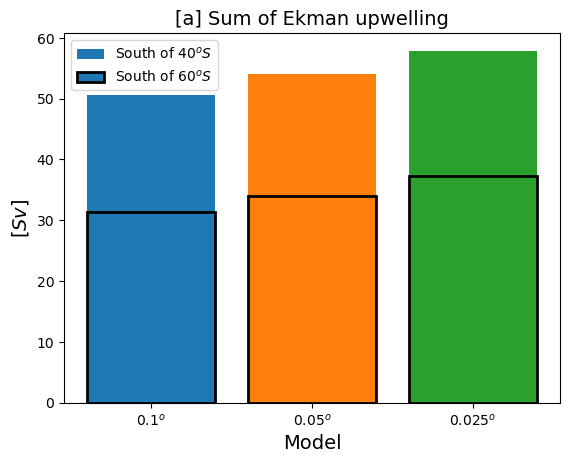

In [168]:
plt.bar([1,2,3],[total_upwelling_01_SV,total_upwelling_005_SV,total_upwelling_0025_SV],color=['tab:blue','tab:orange','tab:green'],label=r'South of $40^oS$')
plt.bar([1,2,3],[total_upwelling_01_SV_60,total_upwelling_005_SV_60,total_upwelling_0025_SV_60],edgecolor='k',color=['tab:blue','tab:orange','tab:green'],linewidth=2,label=r'South of $60^oS$')
plt.ylabel(r'[$Sv$]',fontsize=14)
plt.title(r'[a] Sum of Ekman upwelling',fontsize=14)
plt.xlabel(r'Model',fontsize=14)
plt.xticks(ticks=[1,2,3],labels=[r'$0.1^o$',r'$0.05^o$',r'$0.025^o$'])
plt.legend()

We do see an incrase in Ekman upwelling in the model, which could bring more warmer waters to the surface, and melt sea ice

## Mixed layer depth

The theory of EIP suggest that mixed layer depth decreases in anticylocnic eddies, due to the differences in EKman pumping Do we see that?

Importing pre-calculated variables

In [170]:
#importing vorticity for sanity check
base_vortdir = '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/'
# # # Panan0025
ζ_0025 = xr.open_mfdataset(base_vortdir + 'panan0025_rerun/EKE_along_contour/vorticity_xyt_*_panan0025.nc')\
    .Surface_Vorticity.sel(time=slice(start_date,end_date)).chunk(chunks={"time":'200gb'}).compute()
# # # Panan005
ζ_005 = xr.open_mfdataset(base_vortdir + 'panan005_rerun/EKE_along_contour/vorticity_xyt_panan005.nc')\
    .Surface_Vorticity.sel(time=slice(start_date,end_date)).chunk(chunks={"time":'200gb'}).compute()
# # # Panan005
ζ_01 = xr.open_mfdataset(base_vortdir + 'panan01_rerun/EKE_along_contour/vorticity_xyt_panan01.nc')\
    .Surface_Vorticity.sel(time=slice(start_date,end_date)).chunk(chunks={"time":'200gb'}).compute()

In [171]:
# Importing detection masks
Detection_masked_0025 = xr.open_dataset(base_vortdir + 'panan0025_rerun/EKE_along_contour/Okubo_Wiess_mask0025_02threshold_panan0025.nc').OkuboWeiss_mask0025
Detection_masked_005 = xr.open_dataset(base_vortdir + 'panan005_rerun/EKE_along_contour/Okubo_Wiess_mask005_02threshold_panan005.nc').OkuboWeiss_mask005
Detection_masked_01 = xr.open_dataset(base_vortdir + 'panan01_rerun/EKE_along_contour/Okubo_Wiess_mask01_02threshold_panan01.nc').OkuboWeiss_mask01

In [172]:
# Importing detection masked
Detection_mask_0025 = xr.open_dataset(base_vortdir + 'panan0025_rerun/EKE_along_contour/Okubo_Wiess_maskNaN_02threshold_panan0025.nc').OkuboWeiss_masknan
Detection_mask_005 = xr.open_dataset(base_vortdir + 'panan005_rerun/EKE_along_contour/Okubo_Wiess_maskNaN_02threshold_panan005.nc').OkuboWeiss_masknan
Detection_mask_01 = xr.open_dataset(base_vortdir + 'panan01_rerun/EKE_along_contour/Okubo_Wiess_maskNaN_02threshold_panan01.nc').OkuboWeiss_masknan

In [173]:
#Importing eddies areas
eddies_area_01 = xr.open_dataset(base_vortdir + 'panan01_rerun/EKE_along_contour/Eddies_Stats_02threshold_panan01.nc')
eddies_area_005 = xr.open_dataset(base_vortdir + 'panan005_rerun/EKE_along_contour/Eddies_Stats_02threshold_panan005.nc')
eddies_area_0025 = xr.open_dataset(base_vortdir + 'panan0025_rerun/EKE_along_contour/Eddies_Stats_02threshold_panan0025.nc')

In [174]:
# Importing ζ in eddies centroid
Eddies_ζ_centroid_0025 = xr.open_dataset(base_vortdir + 'panan0025_rerun/EKE_along_contour/Vorticity_centroid_02threshold_panan0025.nc').VorticityCentroid
Eddies_ζ_centroid_005 = xr.open_dataset(base_vortdir + 'panan005_rerun/EKE_along_contour/Vorticity_centroid_02threshold_panan005.nc').VorticityCentroid
Eddies_ζ_centroid_01 = xr.open_dataset(base_vortdir + 'panan01_rerun/EKE_along_contour/Vorticity_centroid_02threshold_panan01.nc').VorticityCentroid

In [184]:
%%time
#importing mixed layer depth - notice we have a problem that we dont have MLD daily

MLD_0025 = importer("panant-0025-zstar-ACCESSyr2",catalog,"mlotst",frequency = '1mon',start_time = start_date, end_time =end_date).chunk(chunks={'xh':'15gb','yh':'15gb','time':'15gb'}).compute()
MLD_005 = importer("panant-005-zstar-ACCESSyr2",catalog,"mlotst",frequency = '1mon',start_time = start_date, end_time =end_date).chunk(chunks={'xh':'15gb','yh':'15gb','time':'15gb'}).compute()
MLD_01 = importer("panant-01-zstar-ACCESSyr2",catalog,"mlotst",frequency = '1mon',start_time = start_date, end_time =end_date).chunk(chunks={'xh':'15gb','yh':'15gb','time':'15gb'}).compute()


CPU times: user 15.9 s, sys: 5.79 s, total: 21.7 s
Wall time: 27.2 s


In [185]:
#importing daily for interpolation in time
MLD_01d = importer("panant-01-zstar-ACCESSyr2",catalog,"mlotst",frequency = '1day',start_time = start_date, end_time =end_date).chunk(chunks={'xh':'15gb','yh':'15gb','time':'15gb'}).compute()


In [186]:
%%time
#interpoalting MLD into daily data - this willlikely take ages
MLD_0025dint = MLD_0025.interp(time=MLD_01d.time)
MLD_0025dint = MLD_0025dint.isel(time=slice(1,-1))
MLD_0025dint['time']=eddies_area_0025.time
MLD_005dint = MLD_005.interp(time=MLD_01d.time)

CPU times: user 8min 22s, sys: 8min 47s, total: 17min 9s
Wall time: 11min 45s


In [209]:
%%time
#extracting MLD in eddies centroid
MLD_ζ_centroid_01 = MLD_01d.cf.sel({'longitude':eddies_area_01.centroid_lon, 'latitude':eddies_area_01.centroid_lat},method='nearest')
MLD_ζ_centroid_005 = MLD_005dint.cf.sel({'longitude':eddies_area_005.centroid_lon, 'latitude':eddies_area_005.centroid_lat},method='nearest')
MLD_ζ_centroid_0025 = MLD_0025dint.cf.sel({'longitude':eddies_area_0025.centroid_lon, 'latitude':eddies_area_0025.centroid_lat},method='nearest')

CPU times: user 32.4 s, sys: 7.88 s, total: 40.3 s
Wall time: 27.8 s


In [210]:
#calculating eddy masks, to make sure we didnt extract values when eddies dont exist
eddies_mask_01 = (1 + 0*eddies_area_01.area_m2)
eddies_mask_005 = (1 + 0*eddies_area_005.area_m2)
eddies_mask_0025 = (1 + 0*eddies_area_0025.area_m2)

In [211]:
#applying eddies masl to MLD in the centroid
MLD_ζ_centroid_01_masked = MLD_ζ_centroid_01 *eddies_mask_01
MLD_ζ_centroid_005_masked = MLD_ζ_centroid_005 *eddies_mask_005
MLD_ζ_centroid_0025_masked = MLD_ζ_centroid_0025 *eddies_mask_0025

In [259]:
#bins that separate cyclonic and anticyclonic eddies
from xhistogram.xarray import histogram
ζ_bins =  np.linspace(-2,2,3)
ζ_bins

array([-2.,  0.,  2.])

In [260]:
MLD_ζbinned_01 = histogram(Eddies_ζ_centroid_01, 
                          bins = ζ_bins, 
                          dim = ['time','eddy_id'],
                          weights = (MLD_ζ_centroid_01_masked *eddies_area_01.area_m2).fillna(0))/\
histogram(Eddies_ζ_centroid_01, 
                          bins = ζ_bins, 
                          dim = ['time','eddy_id'],
                          weights = eddies_area_01.area_m2.fillna(0))

In [263]:
MLD_ζbinned_005 = histogram(Eddies_ζ_centroid_005, 
                          bins = ζ_bins, 
                          dim = ['time','eddy_id'],
                          weights = (MLD_ζ_centroid_005_masked *eddies_area_005.area_m2).fillna(0),block_size=100000)/\
histogram(Eddies_ζ_centroid_005, 
                          bins = ζ_bins, 
                          dim = ['time','eddy_id'],
                          weights = eddies_area_005.area_m2.fillna(0),block_size=100000)

In [265]:
MLD_ζbinned_0025 = histogram(Eddies_ζ_centroid_0025, 
                          bins = ζ_bins, 
                          dim = ['time','eddy_id'],
                          weights = (MLD_ζ_centroid_0025_masked *eddies_area_0025.area_m2).fillna(0),block_size=100000)/\
histogram(Eddies_ζ_centroid_0025, 
                          bins = ζ_bins, 
                          dim = ['time','eddy_id'],
                          weights = eddies_area_0025.area_m2.fillna(0),block_size=100000)

([<matplotlib.axis.XTick at 0x152ae8f4ffd0>,
 [Text(-1, 0, 'Cyclonic ($ - \\zeta$)'),
  Text(1, 0, 'Anticyclonic ($ + \\zeta$)')])

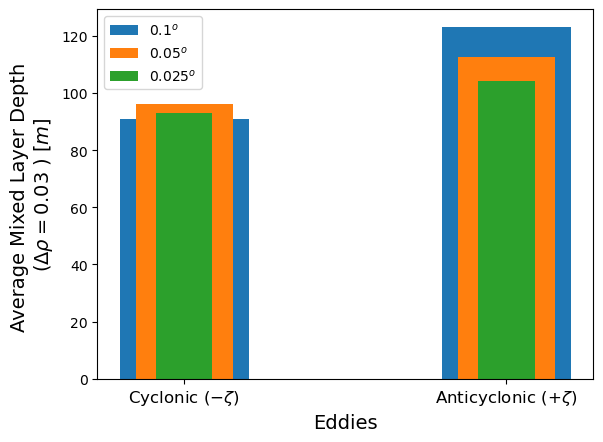

In [278]:
plt.bar(MLD_ζbinned_01.VorticityCentroid_bin,MLD_ζbinned_01,label=r'$0.1^o$')
plt.bar(MLD_ζbinned_005.VorticityCentroid_bin,MLD_ζbinned_005,width=0.6,label=r'$0.05^o$')
plt.bar(MLD_ζbinned_0025.VorticityCentroid_bin,MLD_ζbinned_0025,width=0.35,label=r'$0.025^o$')
plt.legend()
plt.ylabel('Average Mixed Layer Depth \n' + r'($\Delta \rho =0.03$ ) [$m$]',fontsize=14)
plt.xlabel('Eddies',fontsize=14)
plt.xticks(ticks=[-1,1],labels=[r'Cyclonic ($ - \zeta$)',r'Anticyclonic ($ + \zeta$)'],fontsize=12)

We also see that the MLD decreases a lot with resolution mostly in the anticyclone

Im obsessed - let's bin the Ekman pumping into anticyclonic and cyclonic too!

In [281]:
#separation of cyclonic and anticyclonic eddies
ζ_01_cyclonic = (ζ_01.where(ζ_01 <0)*0)+1
ζ_005_cyclonic = (ζ_005.where(ζ_005 <0)*0)+1
ζ_0025_cyclonic = (ζ_0025.where(ζ_0025 <0)*0)+1
#
ζ_01_anticyclonic = (ζ_01.where(ζ_01 >0)*0)+1
ζ_005_anticyclonic = (ζ_005.where(ζ_005 >0)*0)+1
ζ_0025_anticyclonic = (ζ_0025.where(ζ_0025 >0)*0)+1


In [286]:
Me_01_cyclonic = (Me_01*Detection_mask_01* ζ_01_cyclonic).mean('time').sum(('xq','yq'))
Me_005_cyclonic = (Me_005*Detection_mask_005* ζ_005_cyclonic).mean('time').sum(('xq','yq'))
Me_0025_cyclonic = (Me_0025*Detection_mask_0025* ζ_0025_cyclonic).mean('time').sum(('xq','yq'))

In [287]:
Me_01_anticyclonic = (Me_01*Detection_mask_01* ζ_01_anticyclonic).mean('time').sum(('xq','yq'))
Me_005_anticyclonic = (Me_005*Detection_mask_005* ζ_005_anticyclonic).mean('time').sum(('xq','yq'))
Me_0025_anticyclonic = (Me_0025*Detection_mask_0025* ζ_0025_anticyclonic).mean('time').sum(('xq','yq'))

In [295]:
Me_01_cyclonic_withfillaments = (Me_01* ζ_01_cyclonic).mean('time').sum(('xq','yq'))
Me_005_cyclonic_withfillaments = (Me_005*ζ_005_cyclonic).mean('time').sum(('xq','yq'))
Me_0025_cyclonic_withfillaments = (Me_0025*ζ_0025_cyclonic).mean('time').sum(('xq','yq'))

In [296]:
Me_01_anticyclonic_withfillaments = (Me_01* ζ_01_anticyclonic).mean('time').sum(('xq','yq'))
Me_005_anticyclonic_withfillaments = (Me_005* ζ_005_anticyclonic).mean('time').sum(('xq','yq'))
Me_0025_anticyclonic_withfillaments = (Me_0025*ζ_0025_anticyclonic).mean('time').sum(('xq','yq'))

([<matplotlib.axis.XTick at 0x152b059c43d0>,
 [Text(-1, 0, 'Cyclonic ($ - \\zeta$)'),
  Text(1, 0, 'Anticyclonic ($ + \\zeta$)')])

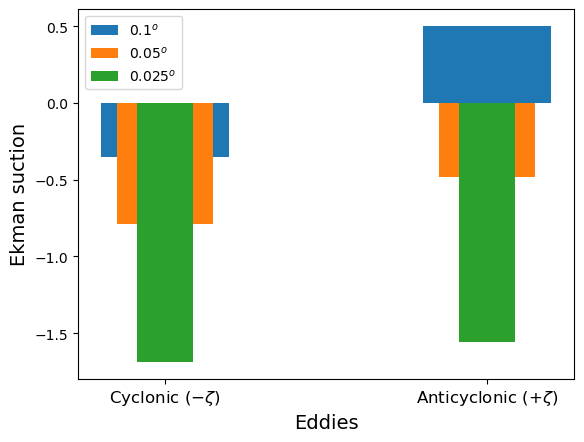

In [297]:
plt.bar(MLD_ζbinned_01.VorticityCentroid_bin,[Me_01_cyclonic_withfillaments*1e-6 ,Me_01_anticyclonic_withfillaments*1e-6],label=r'$0.1^o$')
plt.bar(MLD_ζbinned_005.VorticityCentroid_bin,[Me_005_cyclonic_withfillaments*1e-6 ,Me_005_anticyclonic_withfillaments*1e-6],width=0.6,label=r'$0.05^o$')
plt.bar(MLD_ζbinned_0025.VorticityCentroid_bin,[Me_0025_cyclonic_withfillaments*1e-6 ,Me_0025_anticyclonic_withfillaments*1e-6],width=0.35,label=r'$0.025^o$')
plt.legend()
plt.ylabel('Ekman suction',fontsize=14)
plt.xlabel('Eddies',fontsize=14)
plt.xticks(ticks=[-1,1],labels=[r'Cyclonic ($ - \zeta$)',r'Anticyclonic ($ + \zeta$)'],fontsize=12)

([<matplotlib.axis.XTick at 0x152b06b6ec50>,
 [Text(-1, 0, 'Cyclonic ($ - \\zeta$)'),
  Text(1, 0, 'Anticyclonic ($ + \\zeta$)')])

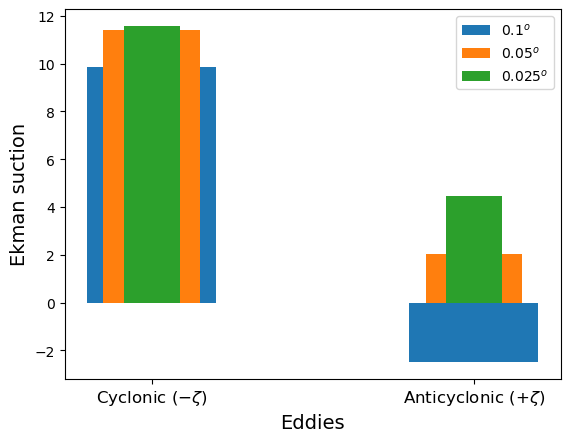

In [294]:
plt.bar(MLD_ζbinned_01.VorticityCentroid_bin,[Me_01_cyclonic*1e-6 ,Me_01_anticyclonic*1e-6],label=r'$0.1^o$')
plt.bar(MLD_ζbinned_005.VorticityCentroid_bin,[Me_005_cyclonic*1e-6 ,Me_005_anticyclonic*1e-6],width=0.6,label=r'$0.05^o$')
plt.bar(MLD_ζbinned_0025.VorticityCentroid_bin,[Me_0025_cyclonic*1e-6 ,Me_0025_anticyclonic*1e-6],width=0.35,label=r'$0.025^o$')
plt.legend()
plt.ylabel('Ekman suction',fontsize=14)
plt.xlabel('Eddies',fontsize=14)
plt.xticks(ticks=[-1,1],labels=[r'Cyclonic ($ - \zeta$)',r'Anticyclonic ($ + \zeta$)'],fontsize=12)